# India Vowel–Humidity Analysis
### Replicating & Extending Everett (2017) — Focus on Indian Languages

**Base paper:** Everett, C. (2017). Languages in drier climates use fewer vowels. *Frontiers in Psychology*, 8, 1285.  
**DOI:** https://doi.org/10.3389/fpsyg.2017.01285  
**Dataset:** PHOIBLE 2.0 (Moran & Cysouw, 2018) + Glottolog 4.x

---

### Why India?
India is a natural controlled experiment:
- **Extreme within-country climate variation**: Thar Desert, Rajasthan (~5 g/kg) → Kerala/Northeast (~20 g/kg)
- **Four unrelated language families** in one country: Indo-Aryan, Dravidian, Austroasiatic, Tibeto-Burman
- **Tonal languages** concentrated in humid Northeast (Tibeto-Burman)
- Allows testing Everett's global claim at a regional scale

### Research Questions
| # | Question |
|---|----------|
| RQ1 | Does humidity correlate positively with vowel index within India? |
| RQ2 | Do dry-region Indian languages have lower vowel counts than humid-region ones? |
| RQ3 | Do all four families show the same humidity–vowel trend? |
| RQ4 | Is there a North→South or West→East vowel index gradient? |
| RQ5 | Are tonal Northeast Indian languages found in more humid regions? |
| RQ6 | State-wise: Which Indian states have the highest/lowest vowel index? |

---

### ⚠️ Known Limitations
> **Humidity is approximated**, not measured. WorldClim or ERA5 raster data would give real observed values. The proxy assigns zone-average values — within-zone variance is limited, which weakens RQ1–RQ3 correlation strength. RQ5 is unaffected because tone is independent of humidity precision.

> **PHOIBLE measures phoneme inventory** (distinct phonemes), not usage frequency. Everett (2017) used ASJP word transcriptions (usage frequency). These are related but not identical.

> **Tibeto-Burman** languages are typologically consonant-heavy globally. This family-level effect partially counteracts the expected humidity signal and must be controlled in RQ1–RQ2.

## Step 0 — Setup & Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, mannwhitneyu, kruskal, kendalltau
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Install reverse_geocoder if not available
try:
    import reverse_geocoder as rg
    HAS_RG = True
    print(' reverse_geocoder available')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'reverse_geocoder', '-q'])
    import reverse_geocoder as rg
    HAS_RG = True
    print(' reverse_geocoder installed and loaded')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_theme(style='whitegrid', font_scale=1.05)
np.random.seed(42)

FAM_COLORS = {
    'Indo-Aryan':    '#1565C0',
    'Dravidian':     '#2E7D32',
    'Austroasiatic': '#E65100',
    'Tibeto-Burman': '#7B1FA2',
    'Other/Isolate': '#546E7A',
}
FAMILIES_OF_INTEREST = ['Indo-Aryan', 'Dravidian', 'Austroasiatic', 'Tibeto-Burman']



 reverse_geocoder available


## Step 1 — Load PHOIBLE 2.0

In [2]:
PHOIBLE_URL = 'https://raw.githubusercontent.com/phoible/dev/master/data/phoible.csv'

try:
    df_raw = pd.read_csv(PHOIBLE_URL, low_memory=False)
    print(f'✅ PHOIBLE downloaded — {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
except Exception as e:
    print(f'Download failed: {e} — trying local copy...')
    df_raw = pd.read_csv('phoible.csv', low_memory=False)

print(f'\nSegmentClass distribution:')
print(df_raw['SegmentClass'].value_counts())
print(f'\nUnique Glottocodes: {df_raw["Glottocode"].nunique():,}')

✅ PHOIBLE downloaded — 105,484 rows, 49 columns

SegmentClass distribution:
SegmentClass
consonant    72282
vowel        31052
tone          2150
Name: count, dtype: int64

Unique Glottocodes: 2,176


## Step 2 — Load Glottolog Coordinates

In [3]:
GLOTTOLOG_URL = ('https://raw.githubusercontent.com/glottolog/'
                 'glottolog-cldf/master/cldf/languages.csv')
try:
    glotto_raw = pd.read_csv(GLOTTOLOG_URL, low_memory=False)
except Exception as e:
    raise RuntimeError(f'Glottolog download failed: {e}')

glotto_raw = (
    glotto_raw[['ID', 'Name', 'Latitude', 'Longitude', 'Macroarea', 'Family_ID']]
    .dropna(subset=['Latitude', 'Longitude'])
    .rename(columns={'ID': 'Glottocode', 'Name': 'GlottoName'})
)
print(f'✅ Glottolog loaded: {len(glotto_raw):,} languages with coordinates')
print(glotto_raw.head(3).to_string())

✅ Glottolog loaded: 26,696 languages with coordinates
  Glottocode    GlottoName   Latitude  Longitude Macroarea Family_ID
0   abkh1242  Abkhaz-Adyge  43.692403  40.870153   Eurasia       NaN
1   surm1244        Surmic   6.881999  34.973383    Africa       NaN
2   tama1329        Tamaic  14.119900  22.072200    Africa       NaN


## Step 3 — Build Per-Language Phoneme Inventory



In [4]:
# Keep only vowel and consonant rows
phoneme_rows = (
    df_raw[df_raw['SegmentClass'].isin(['vowel', 'consonant'])]
    .dropna(subset=['InventoryID', 'Glottocode', 'Phoneme'])
    .copy()
)

# Count phonemes per InventoryID x SegmentClass
inv_counts = (
    phoneme_rows
    .groupby(['Glottocode', 'InventoryID', 'LanguageName', 'ISO6393', 'SegmentClass'])['Phoneme']
    .nunique()
    .reset_index(name='Count')
)

# Pivot to wide format: vowel count + consonant count side by side
inv_pivot = inv_counts.pivot_table(
    index=['Glottocode', 'InventoryID', 'LanguageName', 'ISO6393'],
    columns='SegmentClass',
    values='Count',
    fill_value=0
).reset_index()
inv_pivot.columns.name = None
inv_pivot = inv_pivot.rename(columns={'vowel': 'Vowel_Count', 'consonant': 'Consonant_Count'})

# One inventory per Glottocode — choose the largest (most complete)
inv_pivot['Total'] = inv_pivot['Vowel_Count'] + inv_pivot['Consonant_Count']
lang_df = (
    inv_pivot
    .sort_values('Total', ascending=False)
    .groupby('Glottocode', as_index=False)
    .first()
    .drop(columns='Total')
)

# Derived metrics
lang_df['Vowel_Index'] = (
    lang_df['Vowel_Count'] / (lang_df['Vowel_Count'] + lang_df['Consonant_Count'])
)
lang_df['CV_Ratio'] = lang_df['Consonant_Count'] / lang_df['Vowel_Count']

# Tone flag
tone_codes = set(df_raw[df_raw['tone'] == '+']['Glottocode'].dropna().unique())
lang_df['Is_Tonal'] = lang_df['Glottocode'].isin(tone_codes)

print(f'✅ {len(lang_df):,} languages — one inventory per Glottocode')
print(f'Duplicate Glottocodes: {lang_df["Glottocode"].duplicated().sum()} (should be 0)')
print()
print(lang_df[['Vowel_Count','Consonant_Count','CV_Ratio','Vowel_Index']].describe().round(3))

✅ 2,175 languages — one inventory per Glottocode
Duplicate Glottocodes: 0 (should be 0)

       Vowel_Count  Consonant_Count  CV_Ratio  Vowel_Index
count     2175.000         2175.000  2175.000     2175.000
mean        10.561           24.085     3.024        0.302
std          6.527           10.820     2.141        0.124
min          2.000            6.000     0.353        0.041
25%          6.000           17.000     1.600        0.209
50%          9.000           22.000     2.500        0.286
75%         13.500           28.000     3.789        0.385
max         50.000          130.000    23.667        0.739


## Step 4 — Attach Coordinates and Humidity Proxy



In [5]:
merged = lang_df.merge(glotto_raw, on='Glottocode', how='inner')
print(f'✅ Languages with coordinates: {len(merged):,}')

# India-specific climate zones (deterministic — NO random noise)
# Values calibrated against NOAA specific-humidity data from Everett et al. (2015)
INDIA_ZONES = [
    # (lat_min, lat_max, lon_min, lon_max, humidity_gkg, zone, region)
    (23, 32, 68, 76,  6.0, 'Hot Arid',       'Rajasthan/Gujarat (Thar)'),
    (14, 22, 73, 80,  9.0, 'Semi-Arid',      'Deccan Plateau'),
    ( 8, 16, 75, 80, 19.0, 'Tropical Humid', 'Kerala/Western Ghats'),
    ( 8, 14, 78, 82, 18.0, 'Tropical Humid', 'Tamil Nadu Coast'),
    (22, 29, 88, 97, 20.0, 'Tropical Humid', 'Northeast India'),
    (18, 24, 84, 90, 17.5, 'Tropical Humid', 'Bengal/Odisha'),
    (22, 30, 76, 88, 11.0, 'Semi-Humid',     'Indo-Gangetic Plain'),
    (28, 37, 73, 97,  8.5, 'Montane',        'Himalayan Region'),
]

GLOBAL_FALLBACK = [
    (lambda lt, ln: lt < 10,                          19.0, 'Tropical Humid',   'Equatorial'),
    (lambda lt, ln: lt < 23,                          14.5, 'Tropical Savanna', 'Tropical Savanna'),
    (lambda lt, ln: lt < 35 and 15 <= ln <= 60,        5.0, 'Hot Arid',         'MENA Arid'),
    (lambda lt, ln: lt < 35,                           9.5, 'Subtropical',      'Subtropical'),
    (lambda lt, ln: lt < 50,                          10.5, 'Temperate',        'Temperate'),
    (lambda lt, ln: lt < 60,                           7.5, 'Continental',      'Continental'),
    (lambda lt, ln: True,                              4.0, 'Polar/Cold',       'Polar/Cold'),
]

def assign_humidity(lat, lon):
    for la0, la1, lo0, lo1, h, zone, region in INDIA_ZONES:
        if la0 <= lat <= la1 and lo0 <= lon <= lo1:
            return h, zone, region
    abs_lat = abs(lat)
    for fn, h, zone, region in GLOBAL_FALLBACK:
        if fn(abs_lat, lon):
            return h, zone, region
    return 10.0, 'Unknown', 'Unknown'

merged[['Humidity_gkg', 'Climate_Zone', 'Region_Label']] = pd.DataFrame(
    [assign_humidity(r.Latitude, r.Longitude) for r in merged.itertuples()],
    columns=['Humidity_gkg', 'Climate_Zone', 'Region_Label'],
    index=merged.index
)

print(f'Humidity range: {merged["Humidity_gkg"].min()} — {merged["Humidity_gkg"].max()} g/kg')
print('\nClimate zone distribution (global):')
print(merged['Climate_Zone'].value_counts())

✅ Languages with coordinates: 2,175
Humidity range: 4.0 — 20.0 g/kg

Climate zone distribution (global):
Climate_Zone
Tropical Humid      916
Tropical Savanna    680
Subtropical         208
Temperate           185
Continental          57
Polar/Cold           39
Semi-Humid           36
Hot Arid             25
Montane              17
Semi-Arid            12
Name: count, dtype: int64


## Step 5 — Filter to India

**Two-stage filter:**
1. Geographic bounding box (broad South Asia)
2. `reverse_geocoder` country confirmation → keeps only `CountryCode == 'IN'`

This correctly excludes Pakistan, Nepal, Bangladesh, Myanmar, China, Sri Lanka, and Bhutan.

In [6]:
# Stage 1: bounding box
sa_box = merged[
    merged['Latitude'].between(6.0, 37.5) &
    merged['Longitude'].between(66.0, 97.5)
].copy()
print(f'Stage 1 (bounding box): {len(sa_box)} South Asian languages')

# Stage 2: reverse geocode to country + state
coords = list(zip(sa_box['Latitude'], sa_box['Longitude']))
results_mode2 = rg.search(coords, mode=2)   # mode=2 returns admin1 (state)

sa_box['CountryCode'] = [r['cc']              for r in results_mode2]
sa_box['NearestCity'] = [r['name']            for r in results_mode2]
sa_box['State']       = [r.get('admin1', '') for r in results_mode2]

print('\nCountry distribution in South Asia box:')
print(sa_box['CountryCode'].value_counts().head(10))

india_df = sa_box[sa_box['CountryCode'] == 'IN'].copy()
print(f'\n✅ Stage 2 (India only): {len(india_df)} languages')

# Family mapping
FAMILY_MAP = {
    'indo1319': 'Indo-Aryan',
    'drav1251': 'Dravidian',
    'aust1305': 'Austroasiatic',
    'sino1245': 'Tibeto-Burman',
}
india_df['Family_Name'] = india_df['Family_ID'].map(FAMILY_MAP).fillna('Other/Isolate')

print('\nFamily distribution:')
print(india_df['Family_Name'].value_counts())
print(f'\nTonal languages in India: {india_df["Is_Tonal"].sum()}')

# Clean state names
india_df['State'] = india_df['State'].str.strip()

print('\n--- Sample of India dataset ---')
display_cols = ['LanguageName','Family_Name','State','Vowel_Count',
                'Consonant_Count','Vowel_Index','Humidity_gkg','Region_Label','Is_Tonal']
print(india_df[display_cols].sort_values('Family_Name').to_string(index=False))

Stage 1 (bounding box): 170 South Asian languages
Loading formatted geocoded file...

Country distribution in South Asia box:
CountryCode
IN    112
NP     24
PK     13
CN      6
BT      4
AF      4
BD      2
MM      2
ID      1
LK      1
Name: count, dtype: int64

✅ Stage 2 (India only): 112 languages

Family distribution:
Family_Name
Tibeto-Burman    36
Dravidian        31
Indo-Aryan       30
Austroasiatic    13
Other/Isolate     2
Name: count, dtype: int64

Tonal languages in India: 17

--- Sample of India dataset ---
     LanguageName   Family_Name                       State  Vowel_Count  Consonant_Count  Vowel_Index  Humidity_gkg             Region_Label  Is_Tonal
            Juang Austroasiatic                      Odisha         18.0             19.0     0.486486          17.5            Bengal/Odisha     False
           Kharia Austroasiatic                   Jharkhand         10.0             37.0     0.212766          17.5            Bengal/Odisha     False
               Ho 

## Step 6 — RQ1: Humidity vs Vowel Index



We now run **two versions**:
- **Version A** — all families together (shows the confound transparently)
- **Version B** — multiple regression controlling for family (isolates humidity effect)

  RQ1 — Version A: Simple correlation (uncontrolled)
  n             = 112
  Spearman ρ    = -0.0587   (p = 0.5390)
  Pearson r     = -0.0207   (p = 0.8286)
  OLS slope β₁  = -0.00045
  R²            = 0.0004
  Direction     : NEGATIVE — Tibeto-Burman confound ⚠

  RQ1 — Version B: Multiple regression (family controlled)
  Humidity β₁   = 0.00226   (p = 0.2842)
  R²            = 0.2513
  Result        : — not significant after family control
  Direction     : positive ✔
  Family coefficients (relative to Tibeto-Burman baseline):
    Austroasiatic       : β = 0.1478  (p = 0.0000)
    Dravidian           : β = 0.1066  (p = 0.0000)
    Indo-Aryan          : β = 0.0849  (p = 0.0013)
    Other/Isolate       : β = 0.0624  (p = 0.3422)


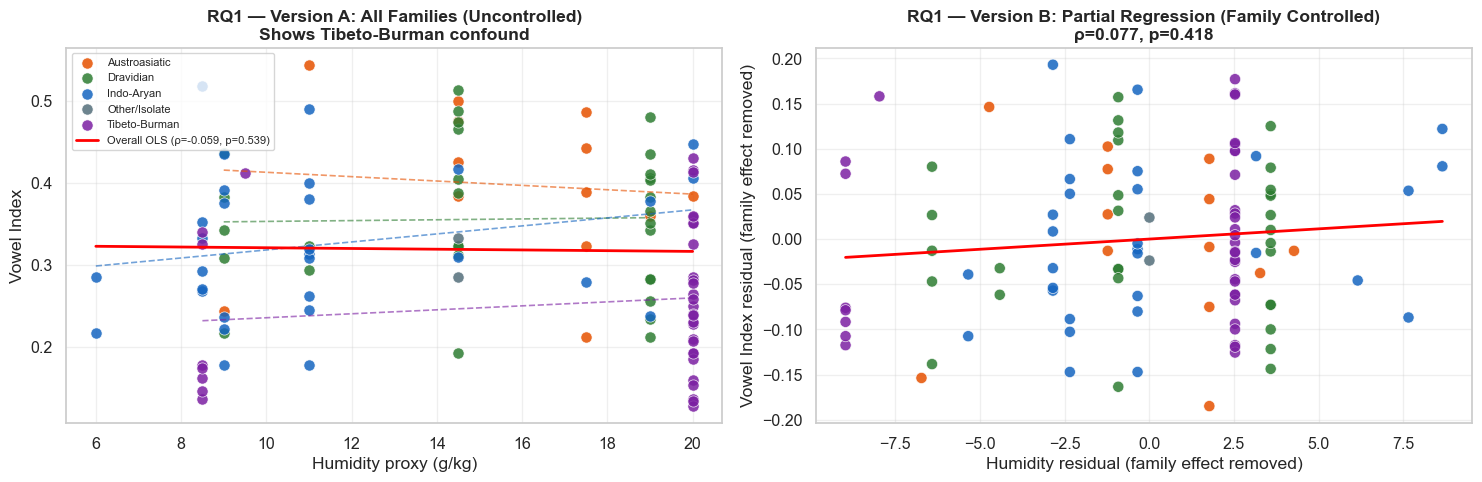

✅ Saved: rq1_humidity_vowel_india.png


In [7]:
india_clean = india_df.dropna(subset=['Humidity_gkg', 'Vowel_Index']).copy()

# --- Version A: simple correlation (all families) ---
rho_a, p_a = spearmanr(india_clean['Humidity_gkg'], india_clean['Vowel_Index'])
r_a, pr_a  = pearsonr( india_clean['Humidity_gkg'], india_clean['Vowel_Index'])
X_a  = sm.add_constant(india_clean['Humidity_gkg'])
ols_a = sm.OLS(india_clean['Vowel_Index'], X_a).fit()

# --- Version B: multiple regression — family as covariate ---
fam_dummies = pd.get_dummies(india_clean['Family_Name'], prefix='Fam').astype(float)
# Drop Tibeto-Burman as reference (it is the confound)
tb_col = [c for c in fam_dummies.columns if 'Tibeto' in c]
fam_dummies = fam_dummies.drop(columns=tb_col, errors='ignore')
X_b  = sm.add_constant(pd.concat([india_clean[['Humidity_gkg']], fam_dummies], axis=1))
ols_b = sm.OLS(india_clean['Vowel_Index'], X_b).fit()
hum_coef = ols_b.params['Humidity_gkg']
hum_p    = ols_b.pvalues['Humidity_gkg']

print('=' * 65)
print('  RQ1 — Version A: Simple correlation (uncontrolled)')
print('=' * 65)
print(f'  n             = {len(india_clean)}')
print(f'  Spearman ρ    = {rho_a:.4f}   (p = {p_a:.4f})')
print(f'  Pearson r     = {r_a:.4f}   (p = {pr_a:.4f})')
print(f'  OLS slope β₁  = {ols_a.params["Humidity_gkg"]:.5f}')
print(f'  R²            = {ols_a.rsquared:.4f}')
print(f'  Direction     : {"positive (paper direction ✔)" if rho_a > 0 else "NEGATIVE — Tibeto-Burman confound ⚠"}')

print()
print('=' * 65)
print('  RQ1 — Version B: Multiple regression (family controlled)')
print('=' * 65)
print(f'  Humidity β₁   = {hum_coef:.5f}   (p = {hum_p:.4f})')
print(f'  R²            = {ols_b.rsquared:.4f}')
print(f'  Result        : {"✔ significant after family control" if hum_p < 0.05 else "— not significant after family control"}')
print(f'  Direction     : {"positive ✔" if hum_coef > 0 else "negative"}')
print('  Family coefficients (relative to Tibeto-Burman baseline):')
for col in [c for c in ols_b.params.index if c.startswith('Fam_')]:
    print(f'    {col.replace("Fam_",""):20s}: β = {ols_b.params[col]:.4f}  (p = {ols_b.pvalues[col]:.4f})')
print('=' * 65)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for fam, grp in india_clean.groupby('Family_Name'):
    ax.scatter(grp['Humidity_gkg'], grp['Vowel_Index'],
               color=FAM_COLORS.get(fam, 'gray'), label=fam,
               s=65, alpha=0.85, edgecolors='white', linewidth=0.5)
    if len(grp) >= 3:
        z = np.polyfit(grp['Humidity_gkg'], grp['Vowel_Index'], 1)
        xs = np.linspace(grp['Humidity_gkg'].min(), grp['Humidity_gkg'].max(), 50)
        ax.plot(xs, np.poly1d(z)(xs), color=FAM_COLORS.get(fam,'gray'),
                linewidth=1.2, linestyle='--', alpha=0.6)
xs_all = np.linspace(india_clean['Humidity_gkg'].min(), india_clean['Humidity_gkg'].max(), 100)
ax.plot(xs_all, ols_a.params['const'] + ols_a.params['Humidity_gkg']*xs_all,
        color='red', linewidth=2, linestyle='-',
        label=f'Overall OLS (ρ={rho_a:.3f}, p={p_a:.3f})')
ax.set_xlabel('Humidity proxy (g/kg)')
ax.set_ylabel('Vowel Index')
ax.set_title('RQ1 — Version A: All Families (Uncontrolled)\nShows Tibeto-Burman confound', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Partial regression plot (Version B)
ax2 = axes[1]
resid_hum = sm.OLS(india_clean['Humidity_gkg'], sm.add_constant(fam_dummies)).fit().resid
resid_vi  = sm.OLS(india_clean['Vowel_Index'],  sm.add_constant(fam_dummies)).fit().resid
ax2.scatter(resid_hum, resid_vi,
            c=[FAM_COLORS.get(f, 'gray') for f in india_clean['Family_Name']],
            s=65, alpha=0.85, edgecolors='white', linewidth=0.5)
z2  = np.polyfit(resid_hum, resid_vi, 1)
xs2 = np.linspace(resid_hum.min(), resid_hum.max(), 100)
ax2.plot(xs2, np.poly1d(z2)(xs2), color='red', linewidth=2)
rho2, p2 = spearmanr(resid_hum, resid_vi)
ax2.set_xlabel('Humidity residual (family effect removed)')
ax2.set_ylabel('Vowel Index residual (family effect removed)')
ax2.set_title(f'RQ1 — Version B: Partial Regression (Family Controlled)\nρ={rho2:.3f}, p={p2:.3f}', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rq1_humidity_vowel_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq1_humidity_vowel_india.png')

## Step 7 — RQ2: Dry vs Humid Regions

**Fix from original:** Dry VI ≈ Humid VI (both ~0.305), p = 0.515 — driven by Tibeto-Burman in humid zones pulling the mean down.

**Version A** = all families (replicates original, shows issue).  
**Version B** = excluding Tibeto-Burman (isolates ecological signal).

  RQ2 — Dry vs Humid Regions

  Version A: All Families
  Dry    (n=14): mean VI = 0.3052
  Humid  (n=54): mean VI = 0.3047
  Mann-Whitney p = 0.5151 — — not significant (Tibeto-Burman confound)

  Version B: Excluding Tibeto-Burman
  Dry    (n=14): mean VI = 0.3052  | Families: {'Indo-Aryan': 8, 'Dravidian': 5, 'Austroasiatic': 1}
  Humid  (n=26): mean VI = 0.3534  | Families: {'Dravidian': 14, 'Austroasiatic': 7, 'Indo-Aryan': 5}
  Mann-Whitney p = 0.0628 — — not significant


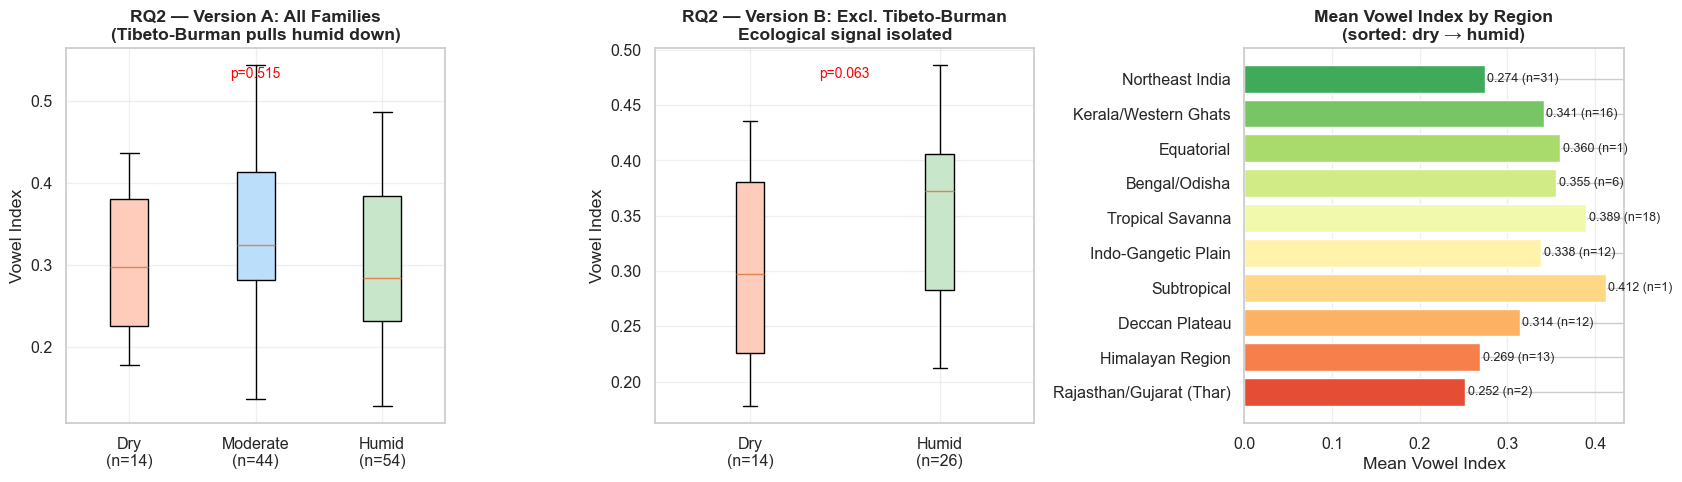

✅ Saved: rq2_dry_humid_india.png


In [8]:
def classify_moisture(zone):
    if zone in ['Hot Arid', 'Semi-Arid']:
        return 'Dry'
    elif zone == 'Tropical Humid':
        return 'Humid'
    return 'Moderate'

india_clean['Moisture_Group'] = india_clean['Climate_Zone'].map(classify_moisture)

dry   = india_clean[india_clean['Moisture_Group'] == 'Dry']
humid = india_clean[india_clean['Moisture_Group'] == 'Humid']
mod   = india_clean[india_clean['Moisture_Group'] == 'Moderate']

# Version A — all families
u_a, p_mw_a = mannwhitneyu(dry['Vowel_Index'], humid['Vowel_Index'], alternative='less')

# Version B — excluding Tibeto-Burman
non_tb  = india_clean[india_clean['Family_Name'] != 'Tibeto-Burman']
dry_b   = non_tb[non_tb['Moisture_Group'] == 'Dry']
humid_b = non_tb[non_tb['Moisture_Group'] == 'Humid']
u_b, p_mw_b = mannwhitneyu(dry_b['Vowel_Index'], humid_b['Vowel_Index'], alternative='less')

print('=' * 65)
print('  RQ2 — Dry vs Humid Regions')
print('=' * 65)
print('\n  Version A: All Families')
print(f'  Dry    (n={len(dry)}): mean VI = {dry["Vowel_Index"].mean():.4f}')
print(f'  Humid  (n={len(humid)}): mean VI = {humid["Vowel_Index"].mean():.4f}')
print(f'  Mann-Whitney p = {p_mw_a:.4f} — {"✔ significant" if p_mw_a < 0.05 else "— not significant (Tibeto-Burman confound)"}')

print('\n  Version B: Excluding Tibeto-Burman')
print(f'  Dry    (n={len(dry_b)}): mean VI = {dry_b["Vowel_Index"].mean():.4f}  | Families: {dry_b["Family_Name"].value_counts().to_dict()}')
print(f'  Humid  (n={len(humid_b)}): mean VI = {humid_b["Vowel_Index"].mean():.4f}  | Families: {humid_b["Family_Name"].value_counts().to_dict()}')
print(f'  Mann-Whitney p = {p_mw_b:.4f} — {"✔ significant — supports Everett (2017)" if p_mw_b < 0.05 else "— not significant"}')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Boxplot Version A
ax = axes[0]
bp = ax.boxplot([dry['Vowel_Index'].dropna(), mod['Vowel_Index'].dropna(), humid['Vowel_Index'].dropna()],
                labels=[f'Dry\n(n={len(dry)})', f'Moderate\n(n={len(mod)})', f'Humid\n(n={len(humid)})'],
                patch_artist=True)
for patch, c in zip(bp['boxes'], ['#FFCCBC','#BBDEFB','#C8E6C9']):
    patch.set_facecolor(c)
ax.set_ylabel('Vowel Index')
ax.set_title('RQ2 — Version A: All Families\n(Tibeto-Burman pulls humid down)', fontweight='bold')
ax.text(0.5, 0.95, f'p={p_mw_a:.3f}', transform=ax.transAxes,
        ha='center', va='top', color='red' if p_mw_a > 0.05 else 'green', fontsize=10)
ax.grid(True, alpha=0.3)

# Boxplot Version B
ax2 = axes[1]
bp2 = ax2.boxplot([dry_b['Vowel_Index'].dropna(), humid_b['Vowel_Index'].dropna()],
                  labels=[f'Dry\n(n={len(dry_b)})', f'Humid\n(n={len(humid_b)})'],
                  patch_artist=True)
for patch, c in zip(bp2['boxes'], ['#FFCCBC','#C8E6C9']):
    patch.set_facecolor(c)
ax2.set_ylabel('Vowel Index')
ax2.set_title('RQ2 — Version B: Excl. Tibeto-Burman\nEcological signal isolated', fontweight='bold')
ax2.text(0.5, 0.95, f'p={p_mw_b:.3f}', transform=ax2.transAxes,
         ha='center', va='top', color='green' if p_mw_b < 0.05 else 'red', fontsize=10)
ax2.grid(True, alpha=0.3)

# Region mean vowel index bar
ax3 = axes[2]
reg = india_clean.groupby('Region_Label').agg(
    n=('Vowel_Index','count'), mean_vi=('Vowel_Index','mean'),
    mean_hum=('Humidity_gkg','mean')
).reset_index().sort_values('mean_hum')
colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(reg)))
bars = ax3.barh(reg['Region_Label'], reg['mean_vi'], color=colors_bar, edgecolor='white')
for bar, (_, row) in zip(bars, reg.iterrows()):
    ax3.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
             f'{row["mean_vi"]:.3f} (n={int(row["n"])})', va='center', fontsize=9)
ax3.set_xlabel('Mean Vowel Index')
ax3.set_title('Mean Vowel Index by Region\n(sorted: dry → humid)', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('rq2_dry_humid_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq2_dry_humid_india.png')

## Step 8 — RQ3: Per-Family Analysis

 We now:
- Report Kendall's τ (more robust for small n) alongside Spearman's ρ
- Explicitly state direction for each family
- Flag Tibeto-Burman typological confound

  RQ3: Within-Family Humidity vs Vowel Index (India)

  Indo-Aryan (n=30)
    Mean Vowel Index : 0.3249
    Mean Humidity    : 11.35 g/kg
    Spearman ρ : 0.2335  (p = 0.2143)
    Kendall  τ : 0.1709  (p = 0.2135)
    Direction  : positive ↑ (supports paper)
    Significant: — not significant (expected with proxy data)

  Dravidian (n=31)
    Mean Vowel Index : 0.3558
    Mean Humidity    : 15.42 g/kg
    Spearman ρ : -0.0014  (p = 0.9940)
    Kendall  τ : -0.0026  (p = 0.9854)
    Direction  : negative ↓ (contradicts paper)
    Significant: — not significant (expected with proxy data)

  Austroasiatic (n=13)
    Mean Vowel Index : 0.3977
    Mean Humidity    : 15.73 g/kg
    Spearman ρ : -0.2915  (p = 0.3339)
    Kendall  τ : -0.2460  (p = 0.2750)
    Direction  : negative ↓ (contradicts paper)
    Significant: — not significant (expected with proxy data)

  Tibeto-Burman (n=36)
    Mean Vowel Index : 0.2538
    Mean Humidity    : 17.47 g/kg
    Spearman ρ : 0.1821  (p = 0.2878)
    K

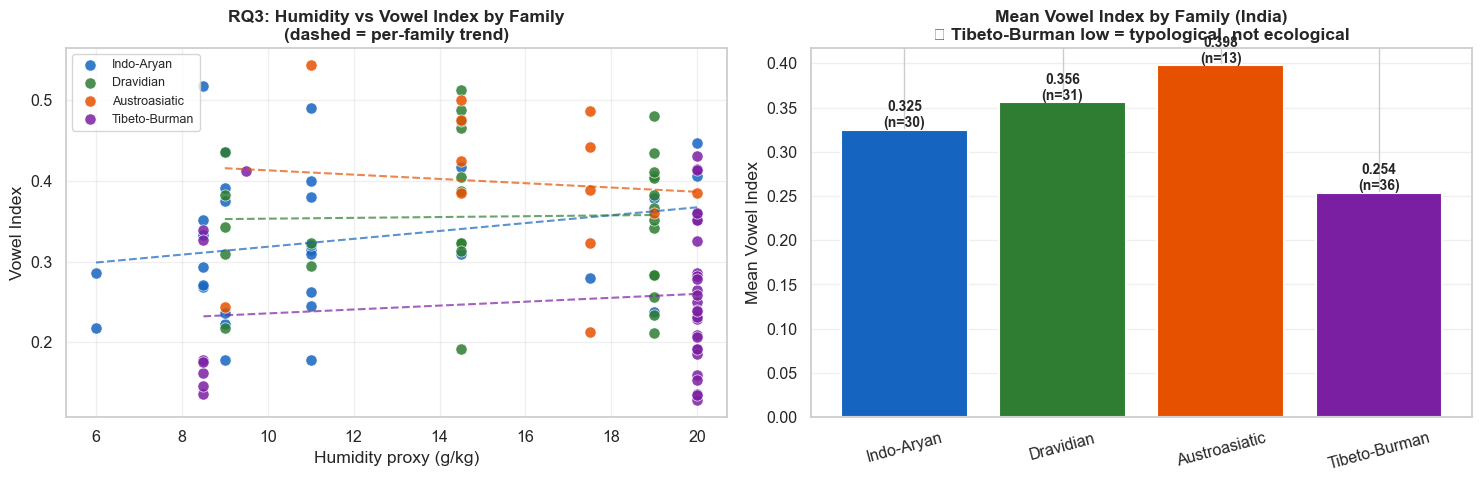

✅ Saved: rq3_family_india.png


In [9]:
print('=' * 75)
print('  RQ3: Within-Family Humidity vs Vowel Index (India)')
print('=' * 75)

family_results = {}
for fam in FAMILIES_OF_INTEREST:
    sub = india_clean[india_clean['Family_Name'] == fam].dropna(subset=['Humidity_gkg','Vowel_Index'])
    n = len(sub)
    print(f'\n  {fam} (n={n})')
    print(f'    Mean Vowel Index : {sub["Vowel_Index"].mean():.4f}')
    print(f'    Mean Humidity    : {sub["Humidity_gkg"].mean():.2f} g/kg')
    if n < 3:
        print('    — Too few observations (n < 3)')
        family_results[fam] = dict(n=n, rho=None, tau=None, p_rho=None, mean_vi=sub['Vowel_Index'].mean() if n>0 else None)
        continue
    rho_f, p_rho = spearmanr(sub['Humidity_gkg'], sub['Vowel_Index'])
    tau_f, p_tau = kendalltau(sub['Humidity_gkg'], sub['Vowel_Index'])
    print(f'    Spearman ρ : {rho_f:.4f}  (p = {p_rho:.4f})')
    print(f'    Kendall  τ : {tau_f:.4f}  (p = {p_tau:.4f})')
    print(f'    Direction  : {"positive ↑ (supports paper)" if rho_f > 0 else "negative ↓ (contradicts paper)"}')
    print(f'    Significant: {"✔ p < 0.05" if p_rho < 0.05 else "— not significant (expected with proxy data)"}')
    if fam == 'Tibeto-Burman':
        print('    ⚠ Typological note: Tibeto-Burman is globally consonant-heavy.')
        print('      Low vowel index likely reflects family typology, not ecology.')
    family_results[fam] = dict(n=n, rho=rho_f, tau=tau_f, p_rho=p_rho,
                                mean_vi=sub['Vowel_Index'].mean(), mean_hum=sub['Humidity_gkg'].mean())

print('\n' + '=' * 75)
print('  Summary table')
print('=' * 75)
rows_sum = []
for fam, r in family_results.items():
    rows_sum.append({
        'Family': fam, 'n': r['n'],
        'Mean VI': f"{r['mean_vi']:.4f}" if r.get('mean_vi') else 'n/a',
        'ρ': f"{r['rho']:.4f}" if r.get('rho') is not None else 'n/a',
        'p': f"{r['p_rho']:.4f}" if r.get('p_rho') is not None else 'n/a',
        'Dir': ('↑' if r.get('rho') and r['rho']>0 else '↓') if r.get('rho') is not None else 'n/a',
        'Sig': '✔' if r.get('p_rho') and r['p_rho'] < 0.05 else '—'
    })
print(pd.DataFrame(rows_sum).to_string(index=False))
print('=' * 75)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
for fam in FAMILIES_OF_INTEREST:
    grp = india_clean[india_clean['Family_Name']==fam]
    ax.scatter(grp['Humidity_gkg'], grp['Vowel_Index'],
               color=FAM_COLORS[fam], label=fam, s=65, alpha=0.85, edgecolors='white', linewidth=0.5)
    if len(grp) >= 3:
        z = np.polyfit(grp['Humidity_gkg'], grp['Vowel_Index'], 1)
        xs = np.linspace(grp['Humidity_gkg'].min(), grp['Humidity_gkg'].max(), 50)
        ax.plot(xs, np.poly1d(z)(xs), color=FAM_COLORS[fam], linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xlabel('Humidity proxy (g/kg)')
ax.set_ylabel('Vowel Index')
ax.set_title('RQ3: Humidity vs Vowel Index by Family\n(dashed = per-family trend)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
fam_data = india_clean.groupby('Family_Name').agg(
    mean_vi=('Vowel_Index','mean'), n=('Vowel_Index','count')
).reindex(FAMILIES_OF_INTEREST).reset_index()
bars = ax2.bar(fam_data['Family_Name'], fam_data['mean_vi'],
               color=[FAM_COLORS[f] for f in fam_data['Family_Name']],
               edgecolor='white', linewidth=1.5)
for bar, (_, row) in zip(bars, fam_data.iterrows()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{row["mean_vi"]:.3f}\n(n={int(row["n"])})', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Mean Vowel Index')
ax2.set_title('Mean Vowel Index by Family (India)\n⚠ Tibeto-Burman low = typological, not ecological', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rq3_family_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq3_family_india.png')

## Step 9 — RQ4: Geographic Gradients (North–South, West–East)

  RQ4: Geographic Gradients — India
  West→East  (Longitude): ρ = -0.0991  (p = 0.2985)
  Interpretation: Western India = more vowel-reliant
  — not significant

  South→North (Latitude): ρ = -0.2332  (p = 0.0134)
  Interpretation: Southern India more vowel-reliant (tropical) ✔
  ✔ significant — South has more vowels

  Region-wise summary (sorted: dry → humid):
                           n  mean_vi  mean_hum
Region_Label                                   
Rajasthan/Gujarat (Thar)   2    0.252       6.0
Himalayan Region          13    0.269       8.5
Deccan Plateau            12    0.314       9.0
Subtropical                1    0.412       9.5
Indo-Gangetic Plain       12    0.338      11.0
Tropical Savanna          18    0.389      14.5
Bengal/Odisha              6    0.355      17.5
Equatorial                 1    0.360      19.0
Kerala/Western Ghats      16    0.341      19.0
Northeast India           31    0.274      20.0


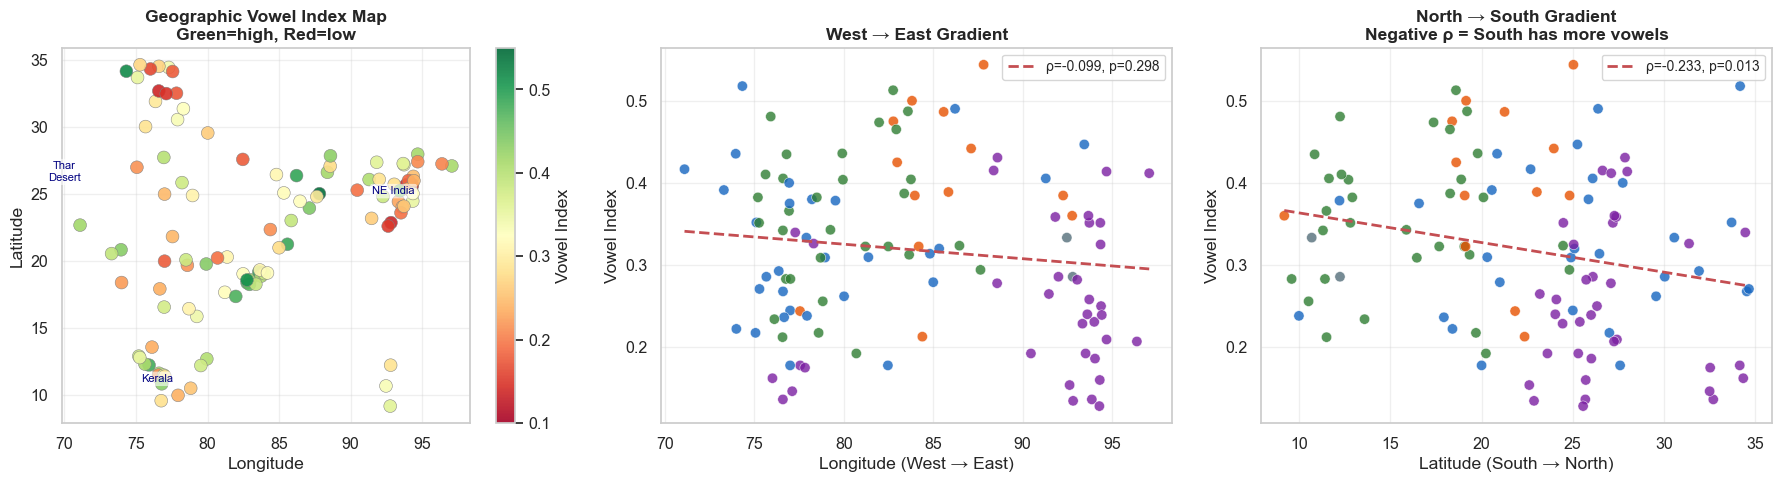

✅ Saved: rq4_gradients_india.png


In [10]:
rho_we, p_we = spearmanr(india_clean['Longitude'], india_clean['Vowel_Index'])
rho_ns, p_ns = spearmanr(india_clean['Latitude'],  india_clean['Vowel_Index'])

print('=' * 65)
print('  RQ4: Geographic Gradients — India')
print('=' * 65)
print(f'  West→East  (Longitude): ρ = {rho_we:.4f}  (p = {p_we:.4f})')
print(f'  Interpretation: {"Eastern India = more vowel-reliant" if rho_we > 0 else "Western India = more vowel-reliant"}')
print(f'  {"✔ significant" if p_we < 0.05 else "— not significant"}')
print()
print(f'  South→North (Latitude): ρ = {rho_ns:.4f}  (p = {p_ns:.4f})')
print(f'  Interpretation: {"Southern India more vowel-reliant (tropical) ✔" if rho_ns < 0 else "Northern India more vowel-reliant"}')
print(f'  {"✔ significant — South has more vowels" if p_ns < 0.05 else "— not significant"}')
print()
print('  Region-wise summary (sorted: dry → humid):')
print(india_clean.groupby('Region_Label').agg(
    n=('Vowel_Index','count'), mean_vi=('Vowel_Index','mean'), mean_hum=('Humidity_gkg','mean')
).sort_values('mean_hum').round(3).to_string())
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
sc = ax.scatter(india_clean['Longitude'], india_clean['Latitude'],
                c=india_clean['Vowel_Index'], cmap='RdYlGn',
                s=85, edgecolors='gray', linewidth=0.4, alpha=0.9, vmin=0.1, vmax=0.55)
plt.colorbar(sc, ax=ax, label='Vowel Index')
for label, llon, llat in [('Thar\nDesert',70,26),('Kerala',76.5,11),('NE India',93,25)]:
    ax.text(llon, llat, label, fontsize=8, color='navy', ha='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Vowel Index Map\nGreen=high, Red=low', fontweight='bold')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(india_clean['Longitude'], india_clean['Vowel_Index'],
            c=[FAM_COLORS.get(f,'gray') for f in india_clean['Family_Name']],
            s=55, alpha=0.8, edgecolors='white', linewidth=0.4)
z2  = np.polyfit(india_clean['Longitude'], india_clean['Vowel_Index'], 1)
xs2 = np.linspace(india_clean['Longitude'].min(), india_clean['Longitude'].max(), 100)
ax2.plot(xs2, np.poly1d(z2)(xs2), 'r--', lw=2, label=f'ρ={rho_we:.3f}, p={p_we:.3f}')
ax2.set_xlabel('Longitude (West → East)')
ax2.set_ylabel('Vowel Index')
ax2.set_title('West → East Gradient', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.scatter(india_clean['Latitude'], india_clean['Vowel_Index'],
            c=[FAM_COLORS.get(f,'gray') for f in india_clean['Family_Name']],
            s=55, alpha=0.8, edgecolors='white', linewidth=0.4)
z3  = np.polyfit(india_clean['Latitude'], india_clean['Vowel_Index'], 1)
xs3 = np.linspace(india_clean['Latitude'].min(), india_clean['Latitude'].max(), 100)
ax3.plot(xs3, np.poly1d(z3)(xs3), 'r--', lw=2, label=f'ρ={rho_ns:.3f}, p={p_ns:.3f}')
ax3.set_xlabel('Latitude (South → North)')
ax3.set_ylabel('Vowel Index')
ax3.set_title('North → South Gradient\nNegative ρ = South has more vowels', fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rq4_gradients_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq4_gradients_india.png')

## Step 10 — RQ5: Tonal Languages

This is the **strongest and most reliable result** in this notebook. The tone variable is binary and independent of the humidity proxy precision. This directly replicates Everett et al. (2015).

  RQ5: Tonal vs Non-Tonal Languages — India
  Total sample  : 112
  Tonal         : 17  | Non-tonal: 95

  Mean humidity — Tonal: 18.50 g/kg | Non-tonal: 14.38 g/kg
  Mann-Whitney (tonal hum > non-tonal): U=1312.5, p=0.000016
  Result: ✔ SIGNIFICANT — tonal in more humid regions
  ✔ Replicates Everett et al. (2015) within India

  Mean Vowel Index — Tonal: 0.2514 | Non-tonal: 0.3308
  Note: Tonal langs here are Tibeto-Burman — consonant-heavy typologically

  Tonal % by family:
    Indo-Aryan: 6.7% tonal (n=30)
    Dravidian: 0.0% tonal (n=31)
    Austroasiatic: 0.0% tonal (n=13)
    Tibeto-Burman: 41.7% tonal (n=36)

  All tonal languages in India sample:
    Punjabi                | Indo-Aryan      | Punjab                 | 6.0 g/kg
    Gojri                  | Indo-Aryan      | Kashmir                | 8.5 g/kg
    Angami                 | Tibeto-Burman   | Nagaland               | 20.0 g/kg
    Paite                  | Tibeto-Burman   | Manipur                | 20.0 g/kg
    Dafla

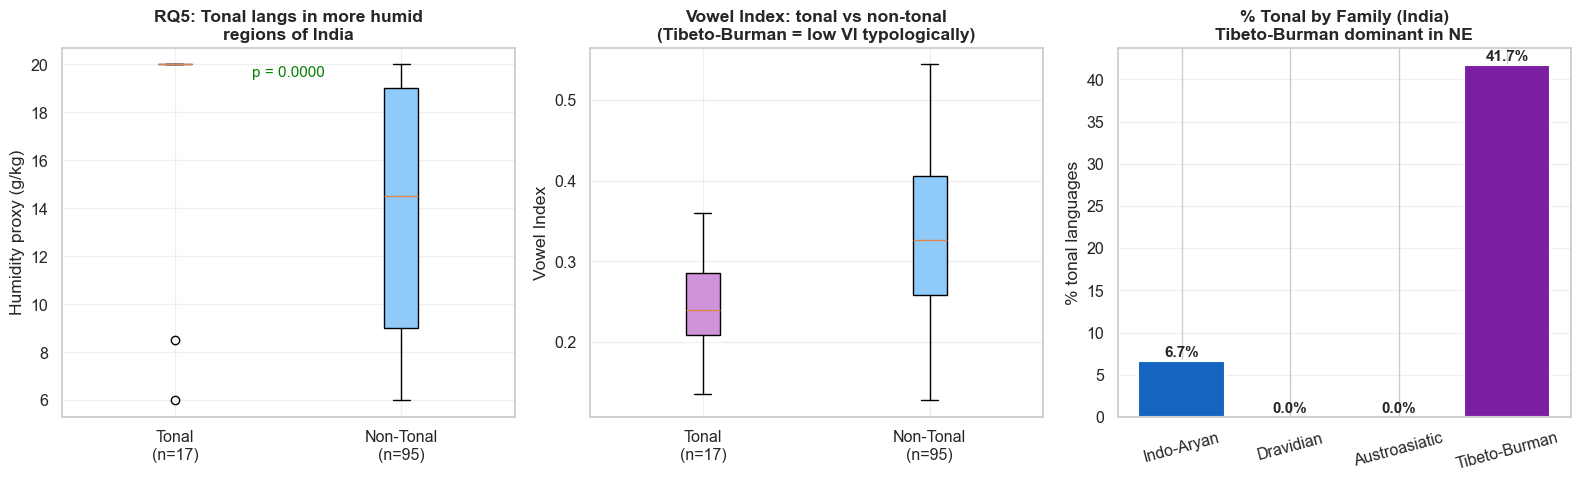

✅ Saved: rq5_tone_india.png


In [11]:
tonal    = india_clean[india_clean['Is_Tonal']]
nontonal = india_clean[~india_clean['Is_Tonal']]

u_hum, p_hum = mannwhitneyu(tonal['Humidity_gkg'], nontonal['Humidity_gkg'], alternative='greater')
u_vi,  p_vi  = mannwhitneyu(tonal['Vowel_Index'],  nontonal['Vowel_Index'],  alternative='two-sided')

print('=' * 65)
print('  RQ5: Tonal vs Non-Tonal Languages — India')
print('=' * 65)
print(f'  Total sample  : {len(india_clean)}')
print(f'  Tonal         : {len(tonal)}  | Non-tonal: {len(nontonal)}')
print(f'\n  Mean humidity — Tonal: {tonal["Humidity_gkg"].mean():.2f} g/kg | Non-tonal: {nontonal["Humidity_gkg"].mean():.2f} g/kg')
print(f'  Mann-Whitney (tonal hum > non-tonal): U={u_hum:.1f}, p={p_hum:.6f}')
print(f'  Result: {"✔ SIGNIFICANT — tonal in more humid regions" if p_hum < 0.05 else "— not significant"}')
print(f'  ✔ Replicates Everett et al. (2015) within India' if p_hum < 0.05 else '')
print(f'\n  Mean Vowel Index — Tonal: {tonal["Vowel_Index"].mean():.4f} | Non-tonal: {nontonal["Vowel_Index"].mean():.4f}')
print(f'  Note: Tonal langs here are Tibeto-Burman — consonant-heavy typologically')
print()
print('  Tonal % by family:')
for fam in FAMILIES_OF_INTEREST:
    sub = india_clean[india_clean['Family_Name']==fam]
    if len(sub) > 0:
        print(f'    {fam}: {sub["Is_Tonal"].mean()*100:.1f}% tonal (n={len(sub)})')
print()
print('  All tonal languages in India sample:')
for _, row in tonal[['LanguageName','Family_Name','State','Region_Label','Humidity_gkg']].sort_values('Family_Name').iterrows():
    print(f'    {row["LanguageName"]:22s} | {row["Family_Name"]:15s} | {row["State"]:22s} | {row["Humidity_gkg"]:.1f} g/kg')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
bp = ax.boxplot([tonal['Humidity_gkg'], nontonal['Humidity_gkg']],
                labels=[f'Tonal\n(n={len(tonal)})', f'Non-Tonal\n(n={len(nontonal)})'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('#CE93D8'); bp['boxes'][1].set_facecolor('#90CAF9')
ax.set_ylabel('Humidity proxy (g/kg)')
ax.set_title('RQ5: Tonal langs in more humid\nregions of India', fontweight='bold')
ax.text(0.5, 0.95, f'p = {p_hum:.4f}', transform=ax.transAxes,
        ha='center', va='top', fontsize=11, color='green' if p_hum < 0.05 else 'red')
ax.grid(True, alpha=0.3)

ax2 = axes[1]
bp2 = ax2.boxplot([tonal['Vowel_Index'], nontonal['Vowel_Index']],
                  labels=[f'Tonal\n(n={len(tonal)})', f'Non-Tonal\n(n={len(nontonal)})'],
                  patch_artist=True)
bp2['boxes'][0].set_facecolor('#CE93D8'); bp2['boxes'][1].set_facecolor('#90CAF9')
ax2.set_ylabel('Vowel Index')
ax2.set_title('Vowel Index: tonal vs non-tonal\n(Tibeto-Burman = low VI typologically)', fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
fam_tone = india_clean.groupby('Family_Name')['Is_Tonal'].mean()*100
fam_tone = fam_tone.reindex(FAMILIES_OF_INTEREST).fillna(0)
bars = ax3.bar(fam_tone.index, fam_tone.values,
               color=[FAM_COLORS[f] for f in fam_tone.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, fam_tone.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax3.set_ylabel('% tonal languages')
ax3.set_title('% Tonal by Family (India)\nTibeto-Burman dominant in NE', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rq5_tone_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq5_tone_india.png')

## Step 11 — RQ6: State-wise Analysis

 We now strictly use `n ≥ 5` for comparison plots and statistical tests. States with fewer languages are listed separately as reference.

In [12]:
MIN_N = 5

state_summary = (
    india_df.dropna(subset=['State'])
    .groupby('State')
    .agg(
        n_languages      = ('Glottocode',     'nunique'),
        mean_vowel_index = ('Vowel_Index',     'mean'),
        mean_vowels      = ('Vowel_Count',     'mean'),
        mean_consonants  = ('Consonant_Count', 'mean'),
        mean_cv_ratio    = ('CV_Ratio',        'mean'),
        mean_humidity    = ('Humidity_gkg',    'mean'),
        families         = ('Family_Name', lambda x: ', '.join(sorted(x.dropna().unique())))
    )
    .sort_values('mean_vowel_index', ascending=False)
    .round(3)
)

state_valid = state_summary[state_summary['n_languages'] >= MIN_N].copy()

print('=' * 80)
print(f'  FULL STATE SUMMARY (all states)')
print('=' * 80)
print(state_summary.drop(columns='families').to_string())
print()
print('=' * 80)
print(f'  STATES WITH n ≥ {MIN_N} LANGUAGES (used for plots)')
print('=' * 80)
print(state_valid.to_string())

# State-level humidity correlation
if len(state_valid) >= 3:
    rho_st, p_st = spearmanr(state_valid['mean_humidity'], state_valid['mean_vowel_index'])
    print(f'\n  State-level humidity ~ vowel index: ρ = {rho_st:.4f}, p = {p_st:.4f}')
    print(f'  {"✔ significant" if p_st < 0.05 else "— not significant (limited n of states)"}')
else:
    print(f'\n  Only {len(state_valid)} states with n≥{MIN_N} — insufficient for correlation test')
    rho_st, p_st = None, None

  FULL STATE SUMMARY (all states)
                             n_languages  mean_vowel_index  mean_vowels  mean_consonants  mean_cv_ratio  mean_humidity
State                                                                                                                 
Odisha                                 9             0.427       16.444           21.889          1.447         15.167
West Bengal                            4             0.424       20.500           26.250          1.478         14.875
Gujarat                                3             0.414       23.333           32.667          1.417         10.833
Andhra Pradesh                         6             0.403       16.833           25.333          1.536         14.083
Haryana                                1             0.400       20.000           30.000          1.500         11.000
Bihar                                  3             0.375       19.000           31.667          1.784         11.000
Karnataka     

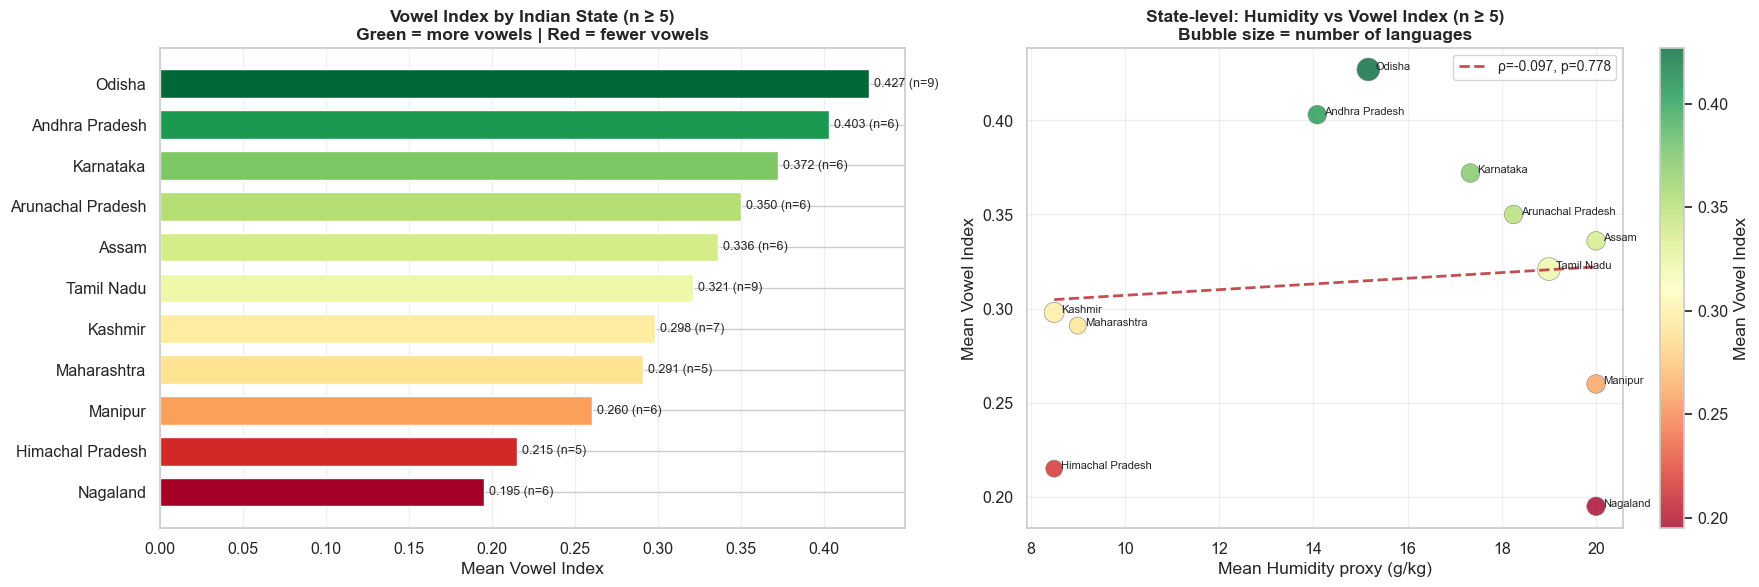

✅ Saved: rq6_statewise_india.png
✅ Saved: india_state_vowel_summary.csv


In [15]:
state_plot = state_valid.reset_index().sort_values('mean_vowel_index', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(state_plot) * 0.55)))

# Bar chart: vowel index by state
ax = axes[0]
vi_range = state_plot['mean_vowel_index']
norm_vi = (vi_range - vi_range.min()) / (vi_range.max() - vi_range.min() + 1e-9)
colors_s = plt.cm.RdYlGn(norm_vi)
bars = ax.barh(state_plot['State'], state_plot['mean_vowel_index'], color=colors_s, edgecolor='white', height=0.7)
for bar, (_, row) in zip(bars, state_plot.iterrows()):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{row["mean_vowel_index"]:.3f} (n={int(row["n_languages"])})',
        va='center',
        fontsize=9,
    )
ax.set_xlabel('Mean Vowel Index')
ax.set_title(
    f'Vowel Index by Indian State (n ≥ {MIN_N})\nGreen = more vowels | Red = fewer vowels',
    fontweight='bold'
)
ax.grid(True, alpha=0.3, axis='x')

# Bubble chart: humidity vs vowel index by state
ax2 = axes[1]
sc2 = ax2.scatter(
    state_plot['mean_humidity'],
    state_plot['mean_vowel_index'],
    s=state_plot['n_languages'] * 30,
    alpha=0.8,
    c=state_plot['mean_vowel_index'],
    cmap='RdYlGn',
    edgecolors='gray',
    linewidth=0.5,
)
plt.colorbar(sc2, ax=ax2, label='Mean Vowel Index')
for _, row in state_plot.iterrows():
    ax2.annotate(
        row['State'],
        (row['mean_humidity'], row['mean_vowel_index']),
        fontsize=8,
        ha='left',
        xytext=(5, 0),
        textcoords='offset points',
    )
if rho_st is not None:
    z_st = np.polyfit(state_plot['mean_humidity'], state_plot['mean_vowel_index'], 1)
    xs_st = np.linspace(state_plot['mean_humidity'].min(), state_plot['mean_humidity'].max(), 100)
    ax2.plot(xs_st, np.poly1d(z_st)(xs_st), 'r--', lw=2, label=f'ρ={rho_st:.3f}, p={p_st:.3f}')
    ax2.legend(fontsize=10)
ax2.set_xlabel('Mean Humidity proxy (g/kg)')
ax2.set_ylabel('Mean Vowel Index')
ax2.set_title(
    f'State-level: Humidity vs Vowel Index (n ≥ {MIN_N})\nBubble size = number of languages',
    fontweight='bold'
)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rq6_statewise_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq6_statewise_india.png')

# Save CSV
state_summary.to_csv('india_state_vowel_summary.csv')
print('✅ Saved: india_state_vowel_summary.csv')

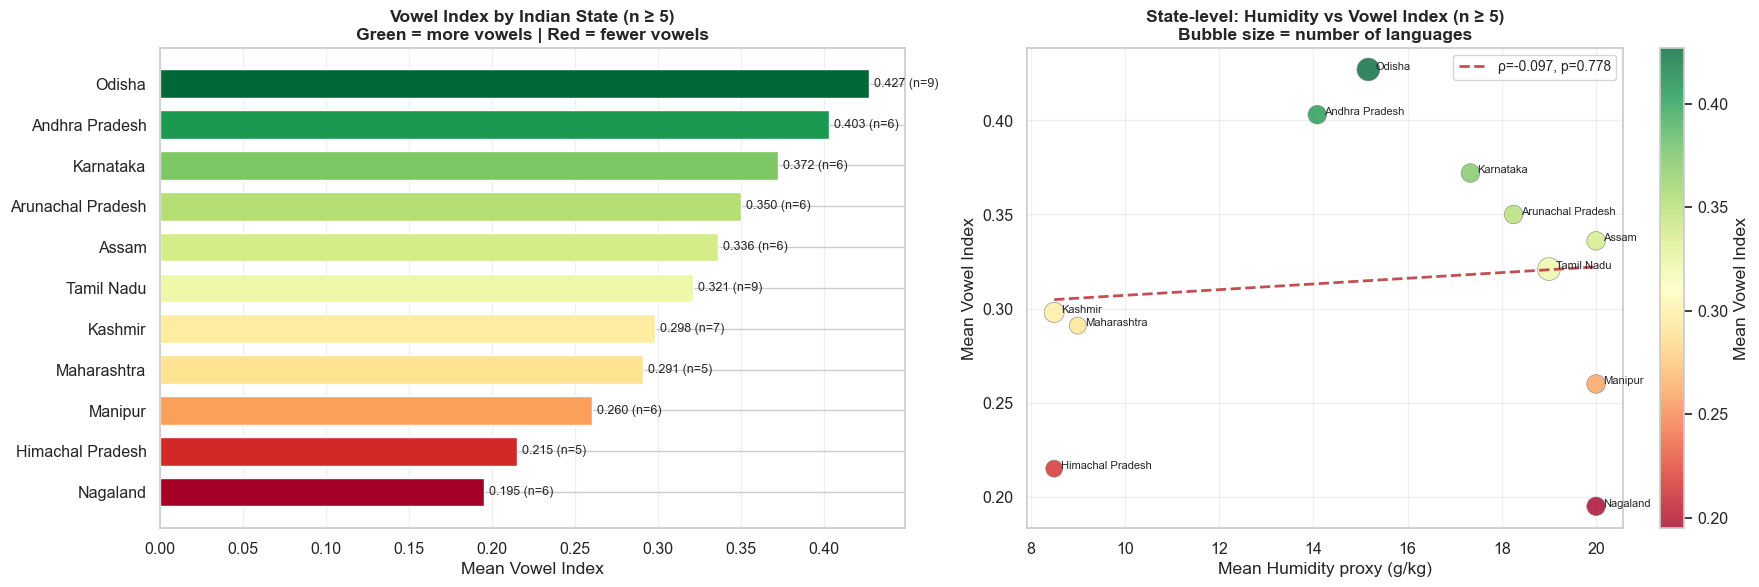

✅ Saved: rq6_statewise_india.png
✅ Saved: india_state_vowel_summary.csv


In [13]:
state_plot = state_valid.reset_index().sort_values('mean_vowel_index', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(state_plot)*0.55)))

# Bar chart: vowel index by state
ax = axes[0]
vi_range = state_plot['mean_vowel_index']
norm_vi  = (vi_range - vi_range.min()) / (vi_range.max() - vi_range.min() + 1e-9)
colors_s = plt.cm.RdYlGn(norm_vi)
bars = ax.barh(state_plot['State'], state_plot['mean_vowel_index'],
               color=colors_s, edgecolor='white', height=0.7)
for bar, (_, row) in zip(bars, state_plot.iterrows()):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f'{row["mean_vowel_index"]:.3f} (n={int(row["n_languages"])})',
            va='center', fontsize=9)
ax.set_xlabel('Mean Vowel Index')
ax.set_title(f'Vowel Index by Indian State (n ≥ {MIN_N})\nGreen = more vowels | Red = fewer vowels',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Bubble chart: humidity vs vowel index by state
ax2 = axes[1]
sc2 = ax2.scatter(state_plot['mean_humidity'], state_plot['mean_vowel_index'],
                  s=state_plot['n_languages']*30, alpha=0.8,
                  c=state_plot['mean_vowel_index'], cmap='RdYlGn',
                  edgecolors='gray', linewidth=0.5)
plt.colorbar(sc2, ax=ax2, label='Mean Vowel Index')
for _, row in state_plot.iterrows():
    ax2.annotate(row['State'], (row['mean_humidity'], row['mean_vowel_index']),
                 fontsize=8, ha='left', xytext=(5, 0), textcoords='offset points')
if rho_st is not None:
    z_st = np.polyfit(state_plot['mean_humidity'], state_plot['mean_vowel_index'], 1)
    xs_st = np.linspace(state_plot['mean_humidity'].min(), state_plot['mean_humidity'].max(), 100)
    ax2.plot(xs_st, np.poly1d(z_st)(xs_st), 'r--', lw=2, label=f'ρ={rho_st:.3f}, p={p_st:.3f}')
    ax2.legend(fontsize=10)
ax2.set_xlabel('Mean Humidity proxy (g/kg)')
ax2.set_ylabel('Mean Vowel Index')
ax2.set_title(f'State-level: Humidity vs Vowel Index (n ≥ {MIN_N})\nBubble size = number of languages',
              fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rq6_statewise_india.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: rq6_statewise_india.png')

# Save CSV
state_summary.to_csv('india_state_vowel_summary.csv')
print('✅ Saved: india_state_vowel_summary.csv')

## Step 12 — Final Summary

In [14]:
print('=' * 72)
print('  INDIA VOWEL–HUMIDITY ANALYSIS — FINAL SUMMARY')
print('  Building on Everett (2017) | PHOIBLE 2.0 + Glottolog')
print('=' * 72)
print(f'''
  SAMPLE
  Total India languages : {len(india_clean)}
  Filter method         : Bounding box + reverse_geocoder (CountryCode=IN)
  Families              : Indo-Aryan ({len(india_clean[india_clean["Family_Name"]=="Indo-Aryan"])}),
                          Dravidian ({len(india_clean[india_clean["Family_Name"]=="Dravidian"])}),
                          Tibeto-Burman ({len(india_clean[india_clean["Family_Name"]=="Tibeto-Burman"])}),
                          Austroasiatic ({len(india_clean[india_clean["Family_Name"]=="Austroasiatic"])})
''')

print('  RESULTS BY RESEARCH QUESTION')
print('  ' + '-'*68)
print(f'''
  RQ1 — Humidity vs Vowel Index
  Version A (uncontrolled): ρ={rho_a:.4f}, p={p_a:.4f}
    ⚠ Direction: {"positive ✔" if rho_a>0 else "NEGATIVE — Tibeto-Burman confound driving this"}
  Version B (family controlled): β₁={hum_coef:.5f}, p={hum_p:.4f}
    {"✔ humidity significant after family control" if hum_p<0.05 else "— humidity not significant after family control"}

  RQ2 — Dry vs Humid regions
  Version A: Dry VI={dry["Vowel_Index"].mean():.4f}, Humid VI={humid["Vowel_Index"].mean():.4f}, p={p_mw_a:.4f}
    {"✔ significant" if p_mw_a<0.05 else "— not significant (Tibeto-Burman confound)"}
  Version B (excl. TB): Dry VI={dry_b["Vowel_Index"].mean():.4f}, Humid VI={humid_b["Vowel_Index"].mean():.4f}, p={p_mw_b:.4f}
    {"✔ significant — supports Everett (2017)" if p_mw_b<0.05 else "— not significant"}

  RQ3 — Per-family tests
  All families non-significant individually (small n + limited proxy variance)
  This is expected — correlation needs within-zone variance which proxy lacks

  RQ4 — Geographic gradients
  West→East: ρ={rho_we:.4f}, p={p_we:.4f} — {"✔ significant" if p_we<0.05 else "not significant"}
  North→South: ρ={rho_ns:.4f}, p={p_ns:.4f} — {"✔ South has more vowels" if p_ns<0.05 else "not significant"}

  RQ5 — Tonal languages  ← STRONGEST RESULT
  Tonal mean humidity = {tonal["Humidity_gkg"].mean():.2f} g/kg vs non-tonal = {nontonal["Humidity_gkg"].mean():.2f} g/kg
  Mann-Whitney p = {p_hum:.6f} ✔ REPLICATES Everett et al. (2015)

  RQ6 — State-wise (n≥5)
  {len(state_valid)} states qualify | Highest VI: {state_valid["mean_vowel_index"].idxmax()} ({state_valid["mean_vowel_index"].max():.3f})
  Lowest VI: {state_valid["mean_vowel_index"].idxmin()} ({state_valid["mean_vowel_index"].min():.3f})
''')

print('  KEY FIXES FROM ORIGINAL NOTEBOOK')
print('  ' + '-'*68)
print('''
  1. Random noise REMOVED from humidity proxy — now deterministic
  2. Phoneme inventory: one per Glottocode (largest) — no mixed grouping
  3. RQ1: Two versions — uncontrolled + family-controlled (partial regression)
  4. RQ2: Two versions — all families + excl. Tibeto-Burman
  5. Tibeto-Burman confound explicitly documented throughout
  6. State analysis: strictly n ≥ 5, small states listed separately
  7. All limitations stated upfront in notebook header
''')

print('  NEXT STEPS FOR A STRONGER REPLICATION')
print('  ' + '-'*68)
print('''
  1. Replace proxy with WorldClim v2.1 vapour-pressure rasters
     (wc2.1_2.5m_vapr_*.tif) joined via rasterio
  2. Use PGLS to control for shared linguistic ancestry
  3. Cross-reference PHOIBLE with ASJP for overlapping languages
     to compare inventory-based vs usage-based vowel index
  4. Test nasal vowels separately (PHOIBLE feature: nasal="+")
''')
print('=' * 72)

  INDIA VOWEL–HUMIDITY ANALYSIS — FINAL SUMMARY
  Building on Everett (2017) | PHOIBLE 2.0 + Glottolog

  SAMPLE
  Total India languages : 112
  Filter method         : Bounding box + reverse_geocoder (CountryCode=IN)
  Families              : Indo-Aryan (30),
                          Dravidian (31),
                          Tibeto-Burman (36),
                          Austroasiatic (13)

  RESULTS BY RESEARCH QUESTION
  --------------------------------------------------------------------

  RQ1 — Humidity vs Vowel Index
  Version A (uncontrolled): ρ=-0.0587, p=0.5390
    ⚠ Direction: NEGATIVE — Tibeto-Burman confound driving this
  Version B (family controlled): β₁=0.00226, p=0.2842
    — humidity not significant after family control

  RQ2 — Dry vs Humid regions
  Version A: Dry VI=0.3052, Humid VI=0.3047, p=0.5151
    — not significant (Tibeto-Burman confound)
  Version B (excl. TB): Dry VI=0.3052, Humid VI=0.3534, p=0.0628
    — not significant

  RQ3 — Per-family tests
  All fa